### A linear regression model for predicting second-hand car prices, built using Pandas for data processing, Seaborn for data visualization, and TensorFlow for model training.

In [241]:
import  tensorflow as tf  # for traning the model and preprocessing the data
import pandas as pd # for data reading and manipulation
import seaborn as sns # for data visualization
from tensorflow.keras.layers import Normalization , Dense ,InputLayer
from tensorflow.keras.losses import MeanSquaredError,Huber,MeanAbsoluteError
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError
import matplotlib.pyplot as plt### plotting bar chart
import numpy as np


### Data Preparation

In [242]:
data = pd.read_csv("train.csv") # reading the data from csv file
data.head() # displaying the first 5 rows of the data

,v.id,on road old,on road now,years,km,rating,condition,economy,top speed,hp,torque,current price
0,1,535651,798186,3,78945,1,2,14,177,73,123,351318.0
1,2,591911,861056,6,117220,5,9,9,148,74,95,285001.5
2,3,686990,770762,2,132538,2,8,15,181,53,97,215386.0
3,4,573999,722381,4,101065,4,3,11,197,54,116,244295.5
4,5,691388,811335,6,61559,3,9,12,160,53,105,531114.5


In [243]:
data.shape # displaying the shape of the data

(1000, 12)

##### Seaborn pairplot is used to create a pairwise plot between different variables of the dataset to visualize the relationship between them . In the exaple below you can see how different variable value changes with respect to each other

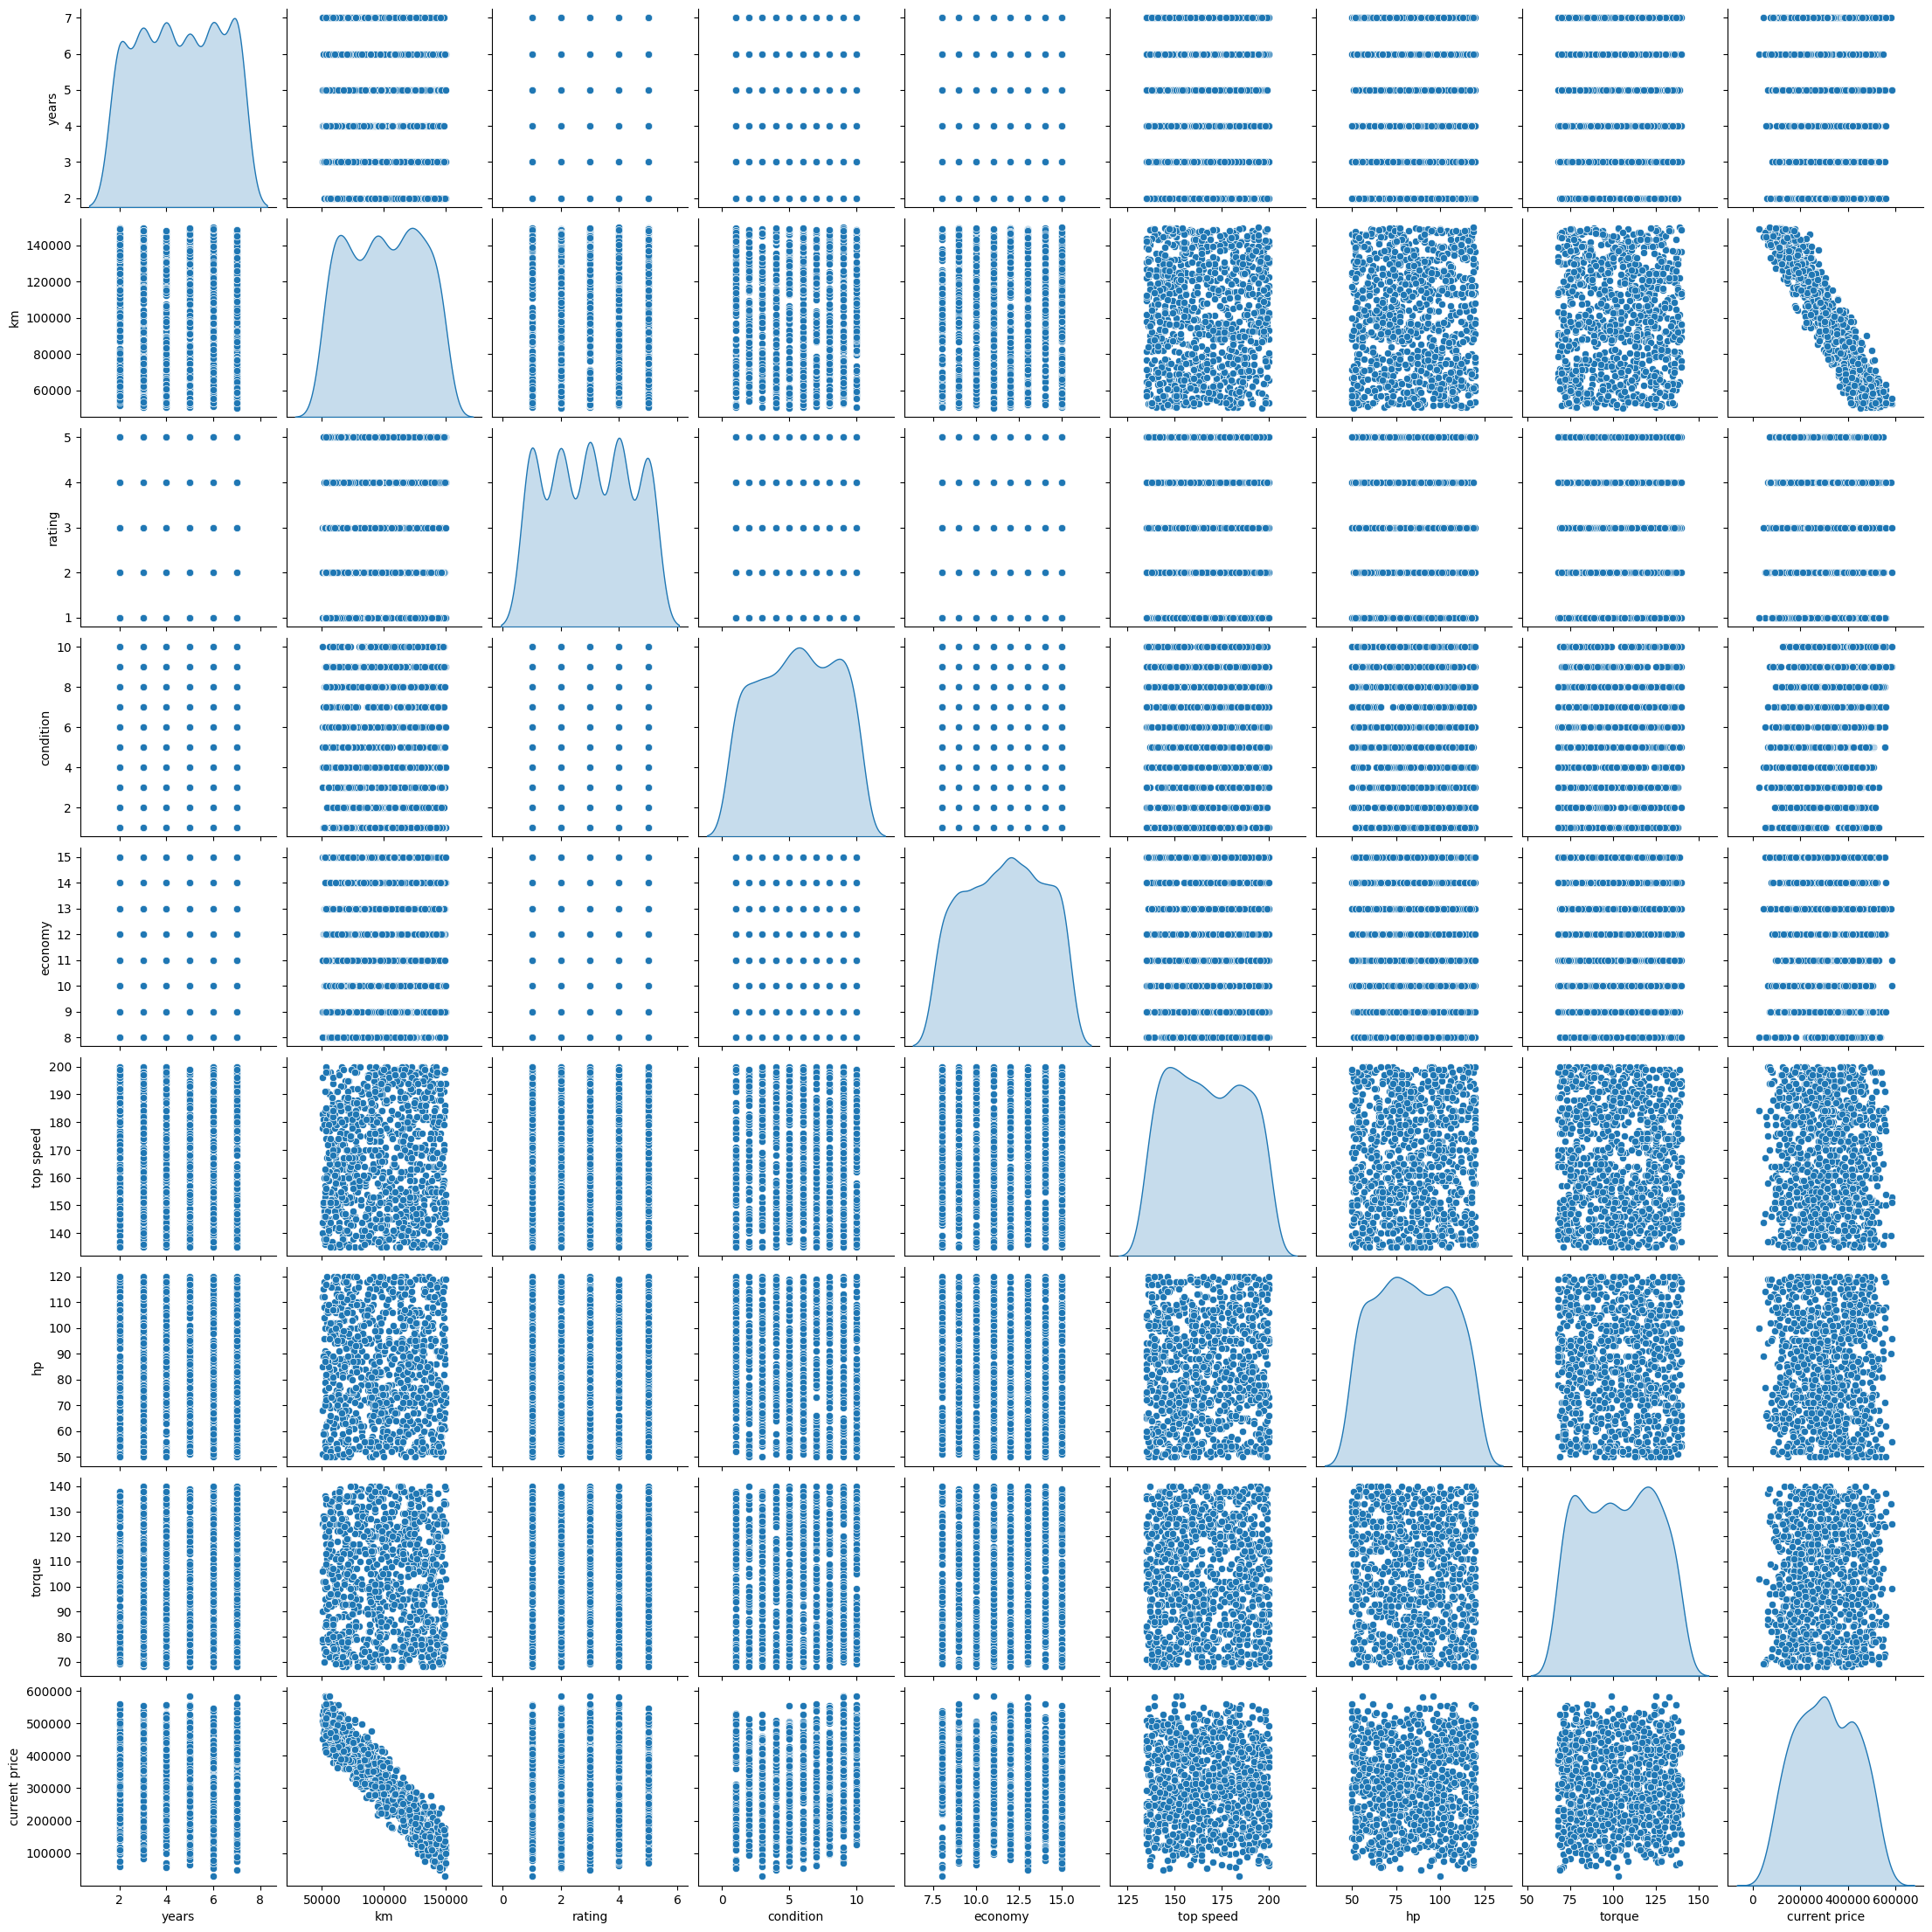

In [244]:
sns.pairplot(data[['years', 'km', 'rating', 'condition', 'economy', 'top speed', 'hp', 'torque', 'current price']], diag_kind='kde')

In [245]:
# Converting the dataset into tensors for model training
tensor_data = tf.constant(data)
print(tensor_data.shape) # displaying the shape of the tensor 
print(tensor_data[:5]) # displaying the first 5 rows of the tensor data

(1000, 12)
tf.Tensor(
[[1.000000e+00 5.356510e+05 7.981860e+05 3.000000e+00 7.894500e+04
  1.000000e+00 2.000000e+00 1.400000e+01 1.770000e+02 7.300000e+01
  1.230000e+02 3.513180e+05]
 [2.000000e+00 5.919110e+05 8.610560e+05 6.000000e+00 1.172200e+05
  5.000000e+00 9.000000e+00 9.000000e+00 1.480000e+02 7.400000e+01
  9.500000e+01 2.850015e+05]
 [3.000000e+00 6.869900e+05 7.707620e+05 2.000000e+00 1.325380e+05
  2.000000e+00 8.000000e+00 1.500000e+01 1.810000e+02 5.300000e+01
  9.700000e+01 2.153860e+05]
 [4.000000e+00 5.739990e+05 7.223810e+05 4.000000e+00 1.010650e+05
  4.000000e+00 3.000000e+00 1.100000e+01 1.970000e+02 5.400000e+01
  1.160000e+02 2.442955e+05]
 [5.000000e+00 6.913880e+05 8.113350e+05 6.000000e+00 6.155900e+04
  3.000000e+00 9.000000e+00 1.200000e+01 1.600000e+02 5.300000e+01
  1.050000e+02 5.311145e+05]], shape=(5, 12), dtype=float64)


In [246]:
tensor_data = tf.random.shuffle(tensor_data) # shuffling the tensor data to avoid any bias in the model training and introduce the randomness in the data 
print(tensor_data[:5])

tf.Tensor(
[[8.050000e+02 6.673700e+05 7.609300e+05 6.000000e+00 6.923000e+04
  2.000000e+00 1.000000e+00 1.300000e+01 1.510000e+02 1.180000e+02
  7.600000e+01 4.336155e+05]
 [9.700000e+01 6.871370e+05 7.736770e+05 3.000000e+00 5.046000e+04
  2.000000e+00 3.000000e+00 9.000000e+00 1.830000e+02 6.800000e+01
  9.000000e+01 5.287940e+05]
 [8.630000e+02 6.282000e+05 7.809490e+05 4.000000e+00 1.075490e+05
  4.000000e+00 2.000000e+00 1.400000e+01 1.410000e+02 9.200000e+01
  8.200000e+01 2.746500e+05]
 [3.400000e+02 6.610270e+05 7.291230e+05 6.000000e+00 1.177270e+05
  4.000000e+00 6.000000e+00 1.300000e+01 2.000000e+02 1.160000e+02
  7.400000e+01 2.249585e+05]
 [1.670000e+02 5.908620e+05 7.431030e+05 3.000000e+00 1.201510e+05
  5.000000e+00 9.000000e+00 1.200000e+01 1.420000e+02 7.000000e+01
  8.000000e+01 2.175620e+05]], shape=(5, 12), dtype=float64)


In [247]:
# Dividing the tensor data into X (inputs) and y (targets)
X = tensor_data[:,3:-1] # all columns except the first 3 and the last column as we dont need the vid , on road old , on road now and price of the car(which we need to predict)
print(X.shape) # displaying the shape of the input data
print(X[:5]) # displaying the first 5 rows of the input data
print("")
print("__"*50)
print("")
y = tensor_data[:,-1] # the last column as the target variable (price of the car)
print(y.shape) # displaying the shape of the target data
print(y[:5]) # displaying the first 5 rows of the target data

(1000, 8)
tf.Tensor(
[[6.00000e+00 6.92300e+04 2.00000e+00 1.00000e+00 1.30000e+01 1.51000e+02
  1.18000e+02 7.60000e+01]
 [3.00000e+00 5.04600e+04 2.00000e+00 3.00000e+00 9.00000e+00 1.83000e+02
  6.80000e+01 9.00000e+01]
 [4.00000e+00 1.07549e+05 4.00000e+00 2.00000e+00 1.40000e+01 1.41000e+02
  9.20000e+01 8.20000e+01]
 [6.00000e+00 1.17727e+05 4.00000e+00 6.00000e+00 1.30000e+01 2.00000e+02
  1.16000e+02 7.40000e+01]
 [3.00000e+00 1.20151e+05 5.00000e+00 9.00000e+00 1.20000e+01 1.42000e+02
  7.00000e+01 8.00000e+01]], shape=(5, 8), dtype=float64)

____________________________________________________________________________________________________

(1000,)
tf.Tensor([433615.5 528794.  274650.  224958.5 217562. ], shape=(5,), dtype=float64)


In [248]:
# The values in the y tensor are 1-dimensional, while the values in the X tensor are 2-dimensional.
# To make them compatible, we need to expand the dimensions of the y tensor.
y = tf.expand_dims(y, axis=1)  # tf.expand_dims adds a new dimension at the specified axis — here, axis=1 (the second axis)

print(y.shape)   # Displaying the shape of the target data after expanding the dimensions
print(y[:5])     # Displaying the first 5 rows of the target data after expanding the dimensions


(1000, 1)
tf.Tensor(
[[433615.5]
 [528794. ]
 [274650. ]
 [224958.5]
 [217562. ]], shape=(5, 1), dtype=float64)


### Splitting the data into testing and validation to remove the bias and variance in the model traning

In [249]:
TRAIN_RATIO = 0.8 # defining the training ratio
VAL_RATIO = 0.1 # defining the validation ratio
TEST_RATIO = 0.1 # defining the testing ratio
DATASET_SIZE = len(X) # getting the size of the dataset

In [250]:
# Training data
X_train = X[:int(TRAIN_RATIO * DATASET_SIZE)] # training data
y_train = y[:int(TRAIN_RATIO * DATASET_SIZE)] # training target data
print(X_train.shape) 
print(y_train.shape) 

(800, 8)
(800, 1)


In [251]:
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)) # creating the training dataset from the training data and target data
train_dataset = train_dataset.shuffle(buffer_size=8,reshuffle_each_iteration=True).batch(32).prefetch(tf.data.AUTOTUNE) # shuffling the training dataset and batching it into 32 samples per batch

In [252]:
# Validation data
X_val = X[int(TRAIN_RATIO*DATASET_SIZE):int((VAL_RATIO+TRAIN_RATIO)*DATASET_SIZE)] # validation data
y_val = y[int(TRAIN_RATIO*DATASET_SIZE):int((VAL_RATIO+TRAIN_RATIO)*DATASET_SIZE)] # validation target data
print(X_val.shape)
print(y_val.shape)

(100, 8)
(100, 1)


In [275]:
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = train_dataset.shuffle(buffer_size = 8, reshuffle_each_iteration = True)
     

In [269]:
# Testing data
X_test = X[int((VAL_RATIO+TRAIN_RATIO)*DATASET_SIZE):] # testing data
y_test = y[int((VAL_RATIO+TRAIN_RATIO)*DATASET_SIZE):] # testing target data
print(X_test.shape)
print(y_test.shape)

(100, 8)
(100, 1)


In [270]:
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)) # creating the testing dataset from the testing data and target data
test_dataset = train_dataset.shuffle(buffer_size=8,reshuffle_each_iteration=True).batch(32).prefetch(tf.data.AUTOTUNE) # shuffling the testing dataset and batching it into 32 samples per batch

In [271]:
normalizer = Normalization() # creating a Normalization layer
normalizer.adapt(X_train) # adapting the mean and variance of the traning data 
normalizer(X)[:5] # displaying the first 5 rows of the normalized input data

<tf.Tensor: shape=(5, 8), dtype=float32, numpy=
array([[ 0.8315477 , -1.0782635 , -0.7477873 , -1.6518611 ,  0.63329804,
        -0.81044465,  1.6237353 , -1.294059  ],
       [-0.9252431 , -1.7246315 , -0.7477873 , -0.941001  , -1.1459415 ,
         0.8536053 , -0.84198046, -0.6266496 ],
       [-0.33964616,  0.24129842,  0.7007111 , -1.2964311 ,  1.078108  ,
        -1.3304603 ,  0.3415631 , -1.0080265 ],
       [ 0.8315477 ,  0.5917904 ,  0.7007111 ,  0.12528907,  0.63329804,
         1.7376318 ,  1.5251067 , -1.3894032 ],
       [-0.9252431 ,  0.6752638 ,  1.4249603 ,  1.1915792 ,  0.18848816,
        -1.2784587 , -0.7433518 , -1.1033707 ]], dtype=float32)>

### Model Traning

In [272]:
model = tf.keras.Sequential([
  InputLayer(input_shape = (8,)), # input layer with 8 features and 32 as the batch size
  normalizer, # adding the normalizer layer to the model
  Dense(64, activation='relu'), # adding a dense layer with 64 output neurons and relu activation function
  Dense(64, activation='relu'), # adding another dense layer with 64 output neurons and relu activation function
  Dense(32, activation='relu'), # adding a dense layer with 32 output neurons and relu activation function
  Dense(1) # adding a dense layer with 1 output neuron (for regression)
],name="second_hand_car_price_prediction_model")

model.summary()

Model: "second_hand_car_price_prediction_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_6 (Normalization) │ (None, 8)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,866 (26.82 KB)

 Trainable params: 6,849 (26.75 KB)

 Non-trainable params: 17 (72.00 B)

In [293]:
model.compile(
  # loss = Huber(), # using Huber loss function to account for outliers in the data this uses Mean Squared Error for small errors and Mean Absolute Error for large errors
  optimizer = Adam(learning_rate=0.001), # using Adam optimizer since it takes account of momentum and adapts the learning rate during training
  loss = MeanAbsoluteError(), # using Mean Absolute Error loss function to minimize the absolute difference between predicted and actual values
  metrics = [RootMeanSquaredError()] # using Root Mean Squared Error as a metric to evaluate the model performance
)

In [294]:
history = model.fit(train_dataset,validation_data=val_dataset,epochs=300,verbose=1) # training the model with 100 epochs and verbose set to 1 to display the training progress

Epoch 1/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 22913.9199 - root_mean_squared_error: 32500.1992 - val_loss: 20950.4766 - val_root_mean_squared_error: 30495.3320
Epoch 2/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22944.8223 - root_mean_squared_error: 32651.5059 - val_loss: 20939.4844 - val_root_mean_squared_error: 30493.3105
Epoch 3/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22832.3398 - root_mean_squared_error: 32501.1797 - val_loss: 20927.3359 - val_root_mean_squared_error: 30489.5391
Epoch 4/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 22888.0430 - root_mean_squared_error: 32518.0352 - val_loss: 20918.9297 - val_root_mean_squared_error: 30487.1270
Epoch 5/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 22708.3535 - root_mean_squared_error: 32293.9316 - val_loss: 20911.0996 - val_root_mean_squared_error: 30484.3516
Epoch 6/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 22814.8203 - root_mean_squared_error: 32494.5859 - val_loss: 20904.3281 - v

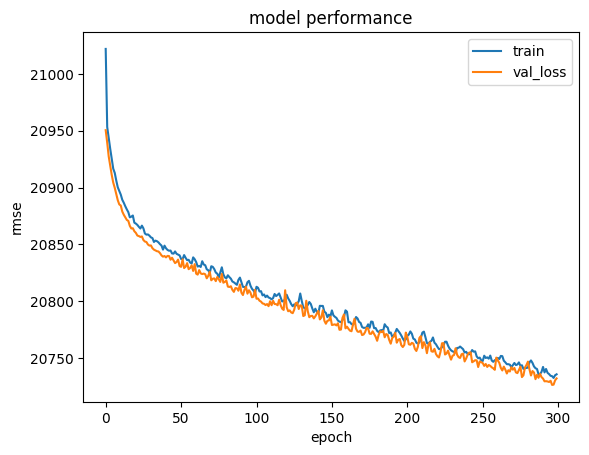

In [295]:
plt.plot(history.history["loss"])
plt.plot(history.history['val_loss'])
plt.title('model performance')
plt.ylabel('rmse')
plt.xlabel('epoch')
plt.legend(['train','val_loss'])
plt.show()

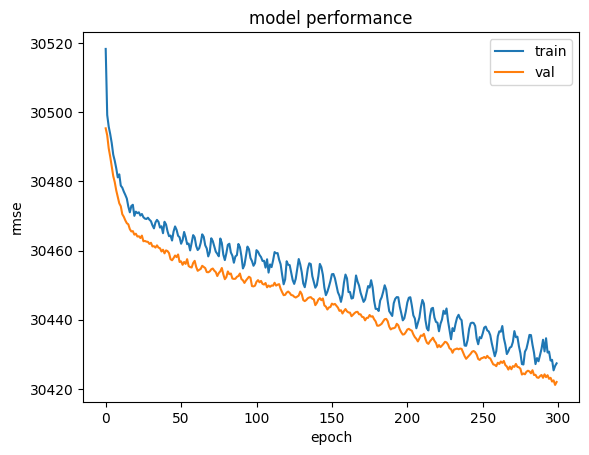

In [296]:
plt.plot(history.history["root_mean_squared_error"])
plt.plot(history.history["val_root_mean_squared_error"])
plt.title('model performance')
plt.ylabel('rmse')
plt.xlabel('epoch')
plt.legend(['train','val'])
plt.show()

In [297]:
model.evaluate(X_test,y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 46148.9219 - root_mean_squared_error: 58858.4922 


[47159.33984375, 58530.25]

In [298]:
X_test[0]

<tf.Tensor: shape=(8,), dtype=float64, numpy=
array([2.000e+00, 8.842e+04, 2.000e+00, 7.000e+00, 1.500e+01, 1.730e+02,
       1.190e+02, 7.200e+01])>

In [299]:
print("# This is the predicted value of the car")
print(model.predict(X_test[:5]))
print("")
print("_"*100)
print("")
print("# This is the actual value of the car")
print(y_test[:5])

# This is the predicted value of the car
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
[[344727.5 ]
 [404415.38]
 [355163.12]
 [329718.75]
 [228842.88]]

____________________________________________________________________________________________________

# This is the actual value of the car
tf.Tensor(
[[401011.5]
 [382241. ]
 [472972.5]
 [398513.5]
 [242173.5]], shape=(5, 1), dtype=float64)


In [300]:
y_true = list(y_test[:,0].numpy())
y_pred = list(model.predict(X_test)[:,0])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  


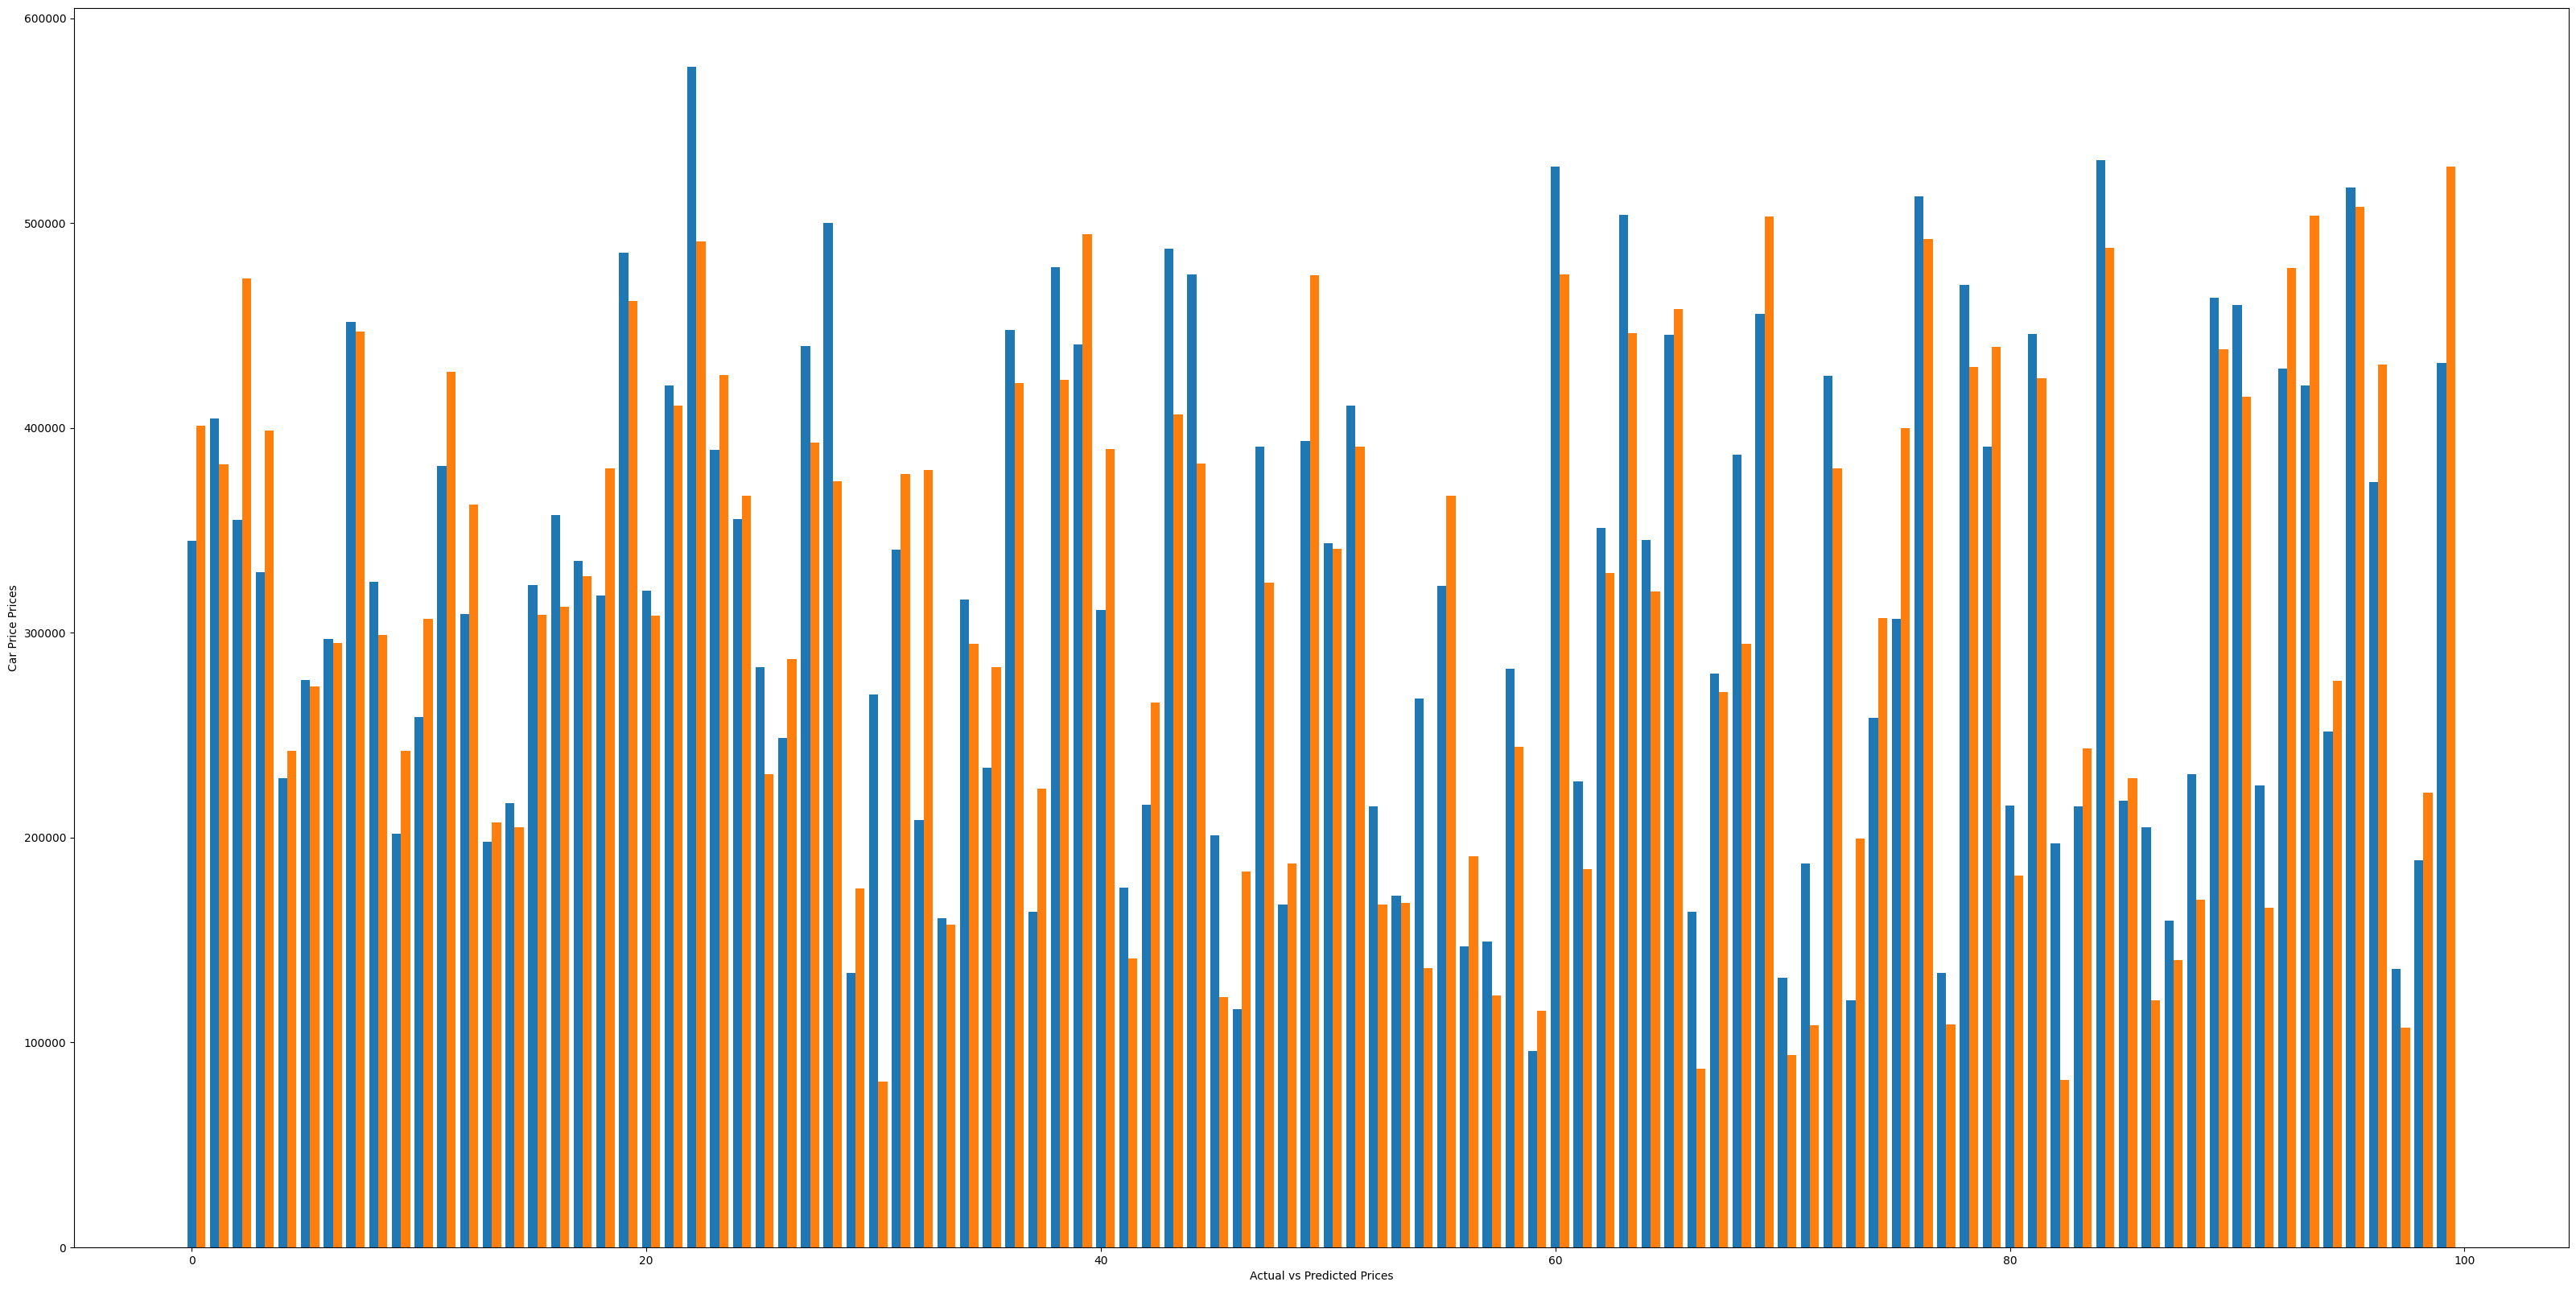

In [301]:
ind = np.arange(100)
plt.figure(figsize=(40,20))

width = 0.4

plt.bar(ind, y_pred, width, label='Predicted Car Price')
plt.bar(ind + width, y_true, width, label='Actual Car Price')

plt.xlabel('Actual vs Predicted Prices')
plt.ylabel('Car Price Prices')

plt.show()